Loading weights from /Users/christiankwok/my wunderfund_challenge/wunderfund_challenge/competition_package/examples/raw_delta_rm_bias_adjusted/lstm_weights.pt
Loading bias from /Users/christiankwok/my wunderfund_challenge/wunderfund_challenge/competition_package/examples/raw_delta_rm_bias_adjusted/delta_bias.npy
Prediction shape: (899, 32)
Truth shape: (899, 32)


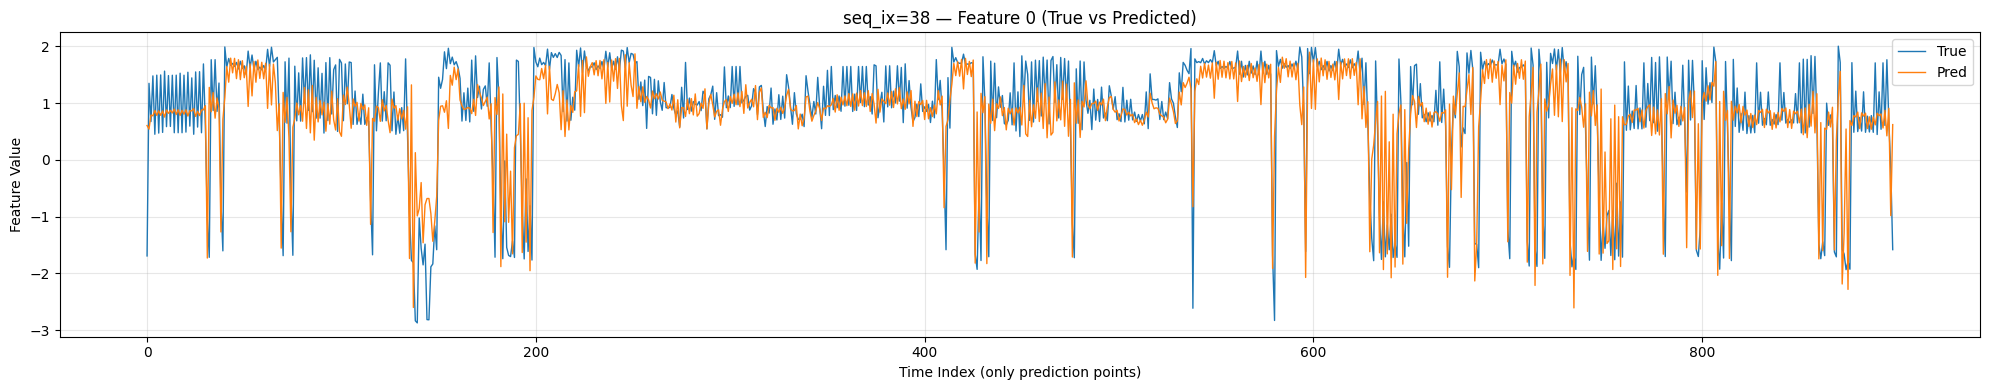

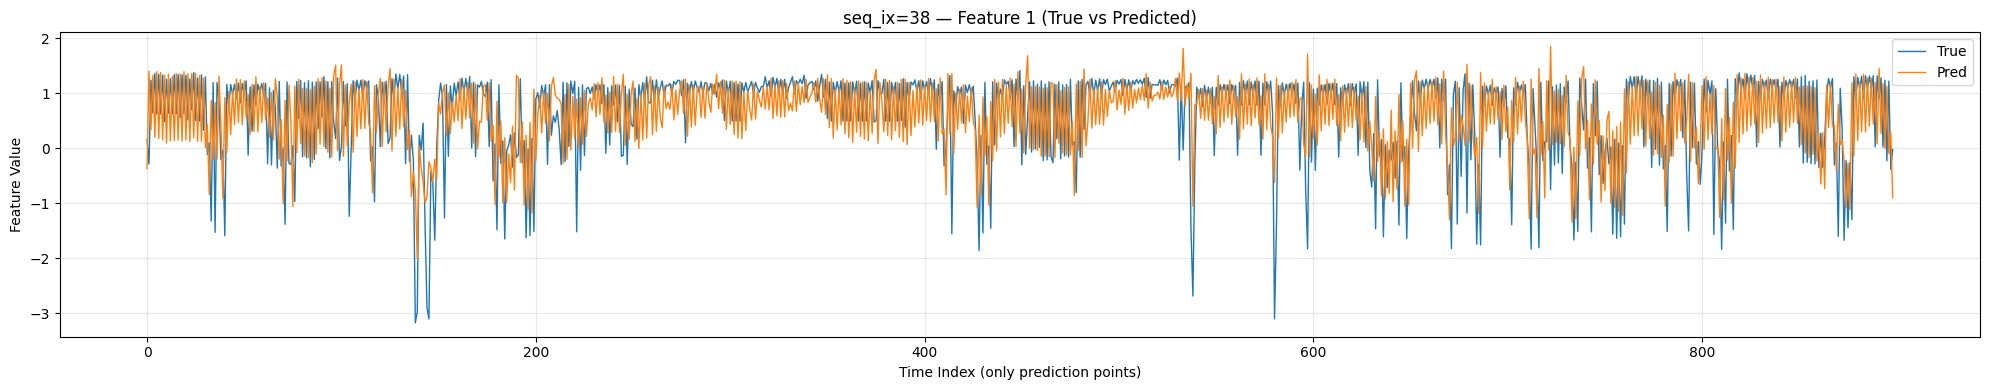

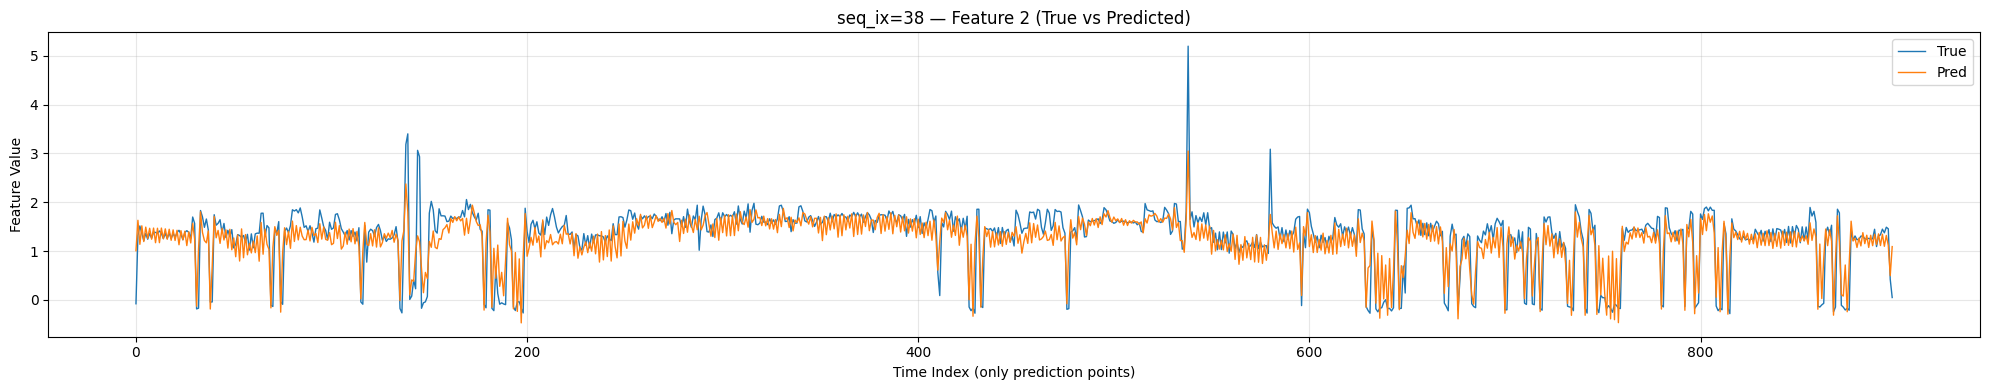

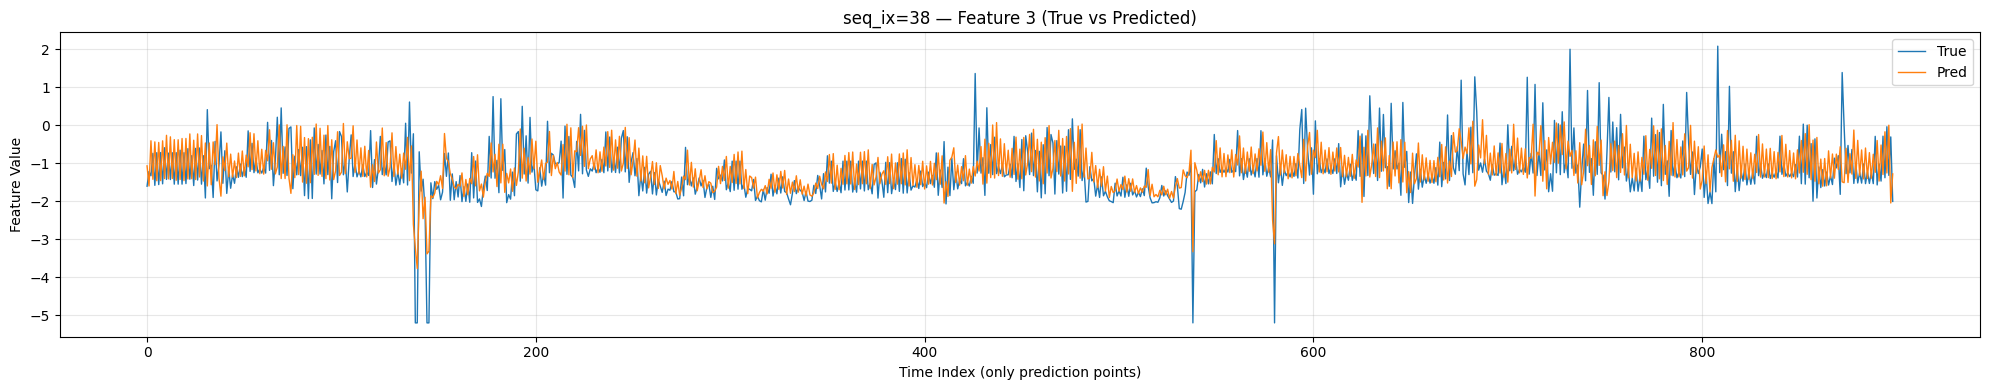

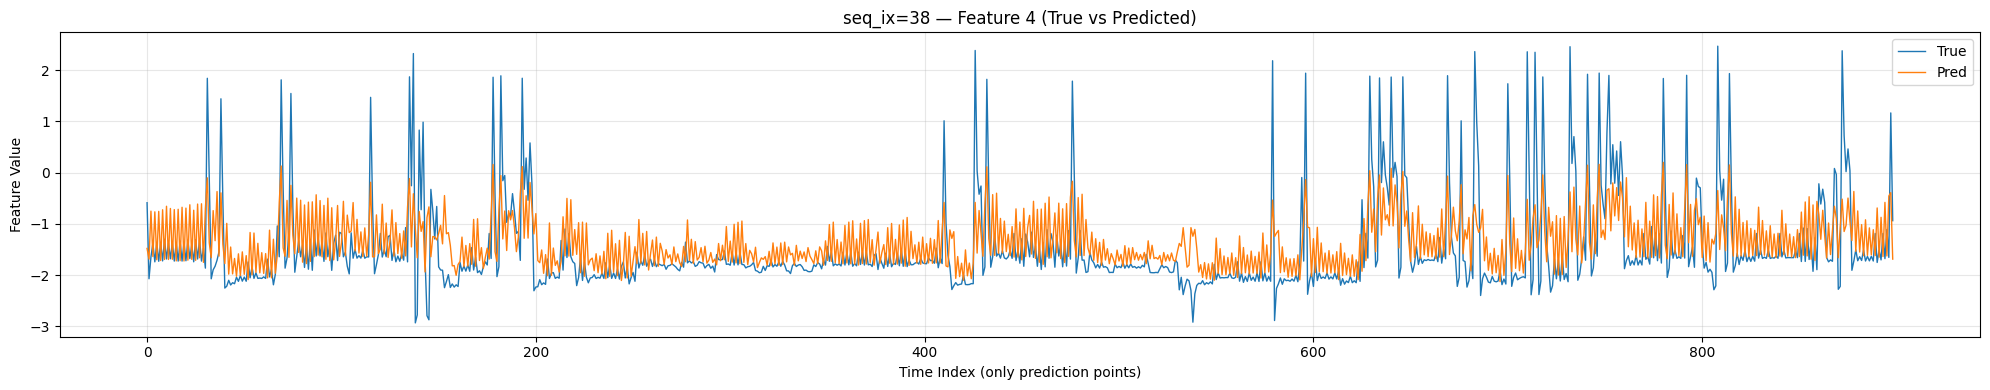

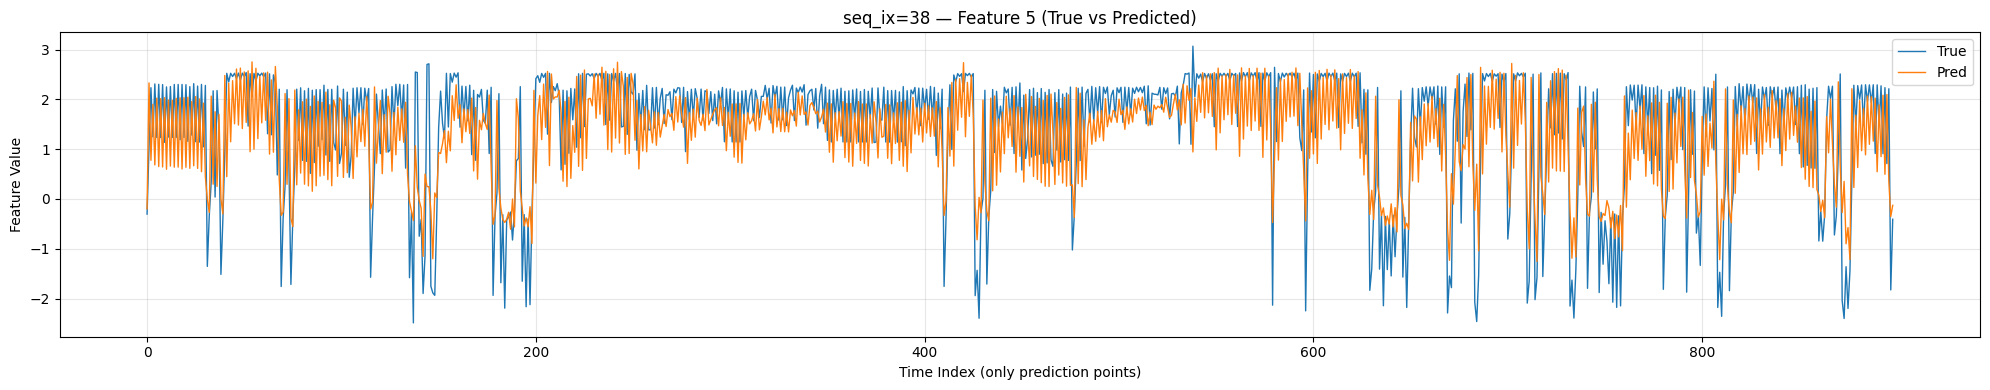

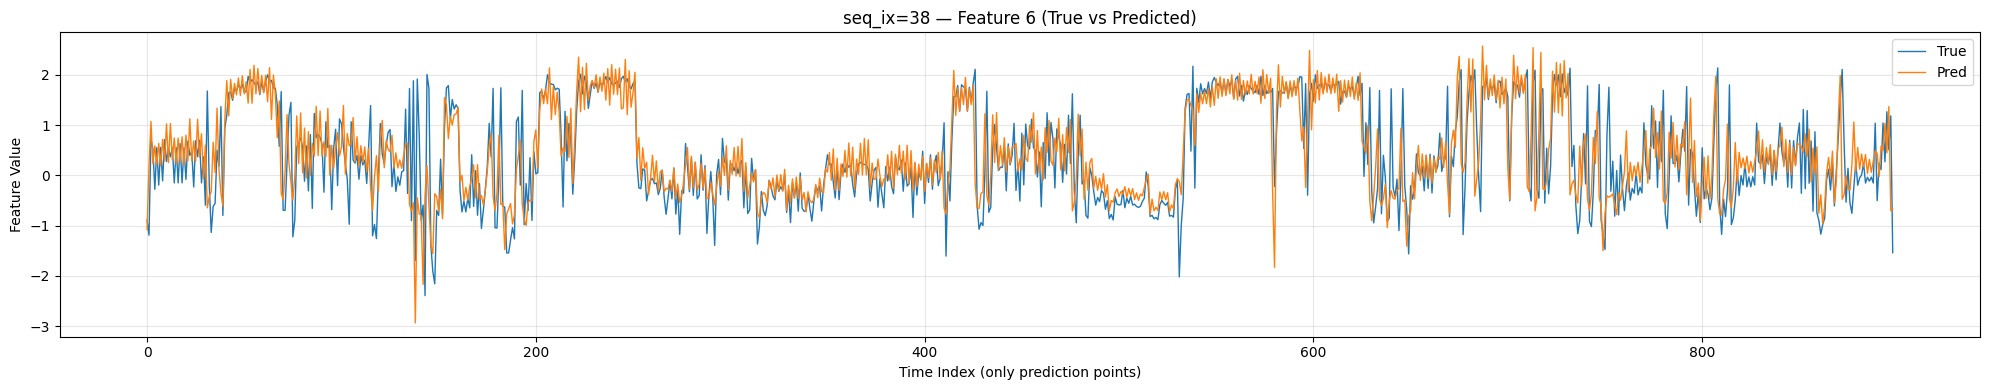

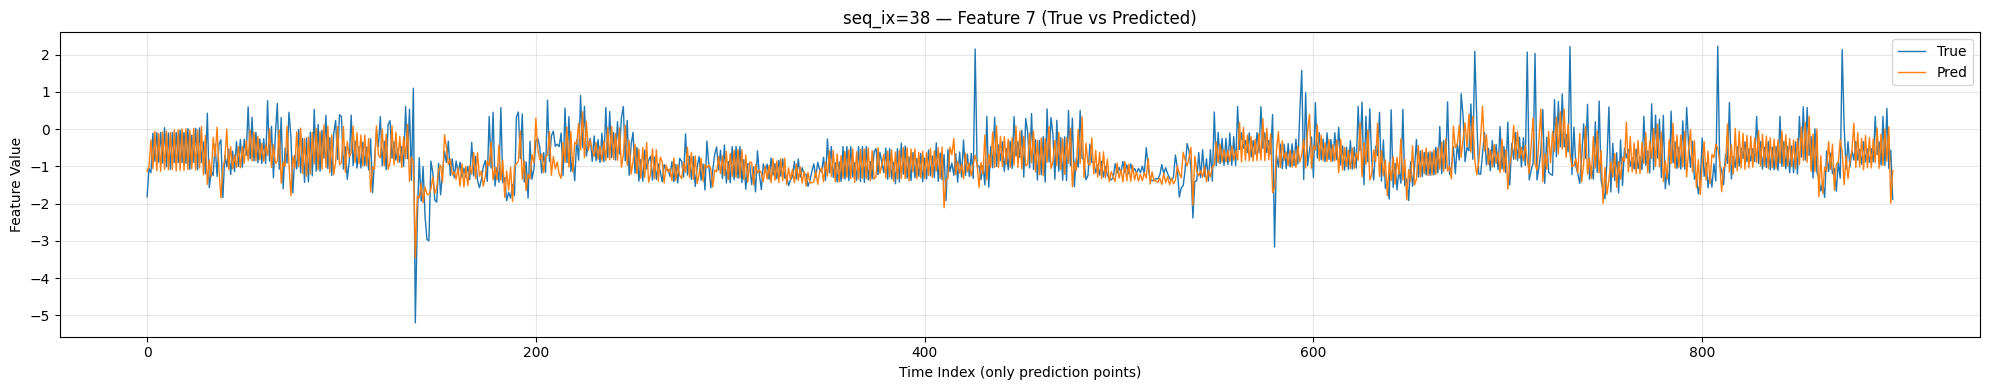

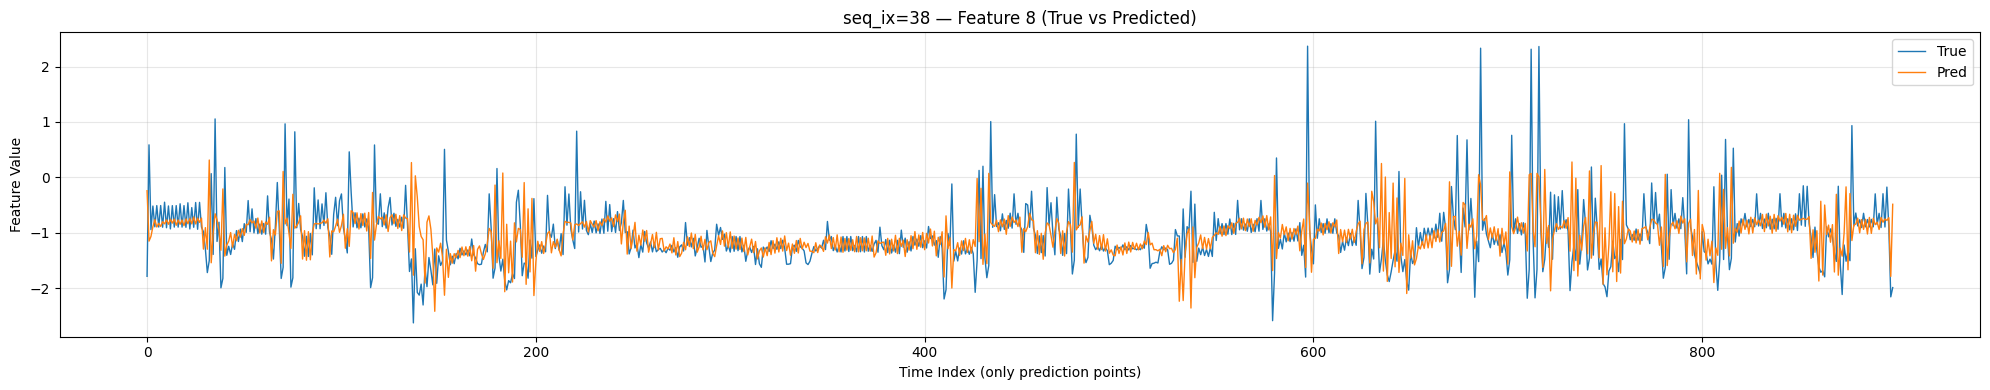

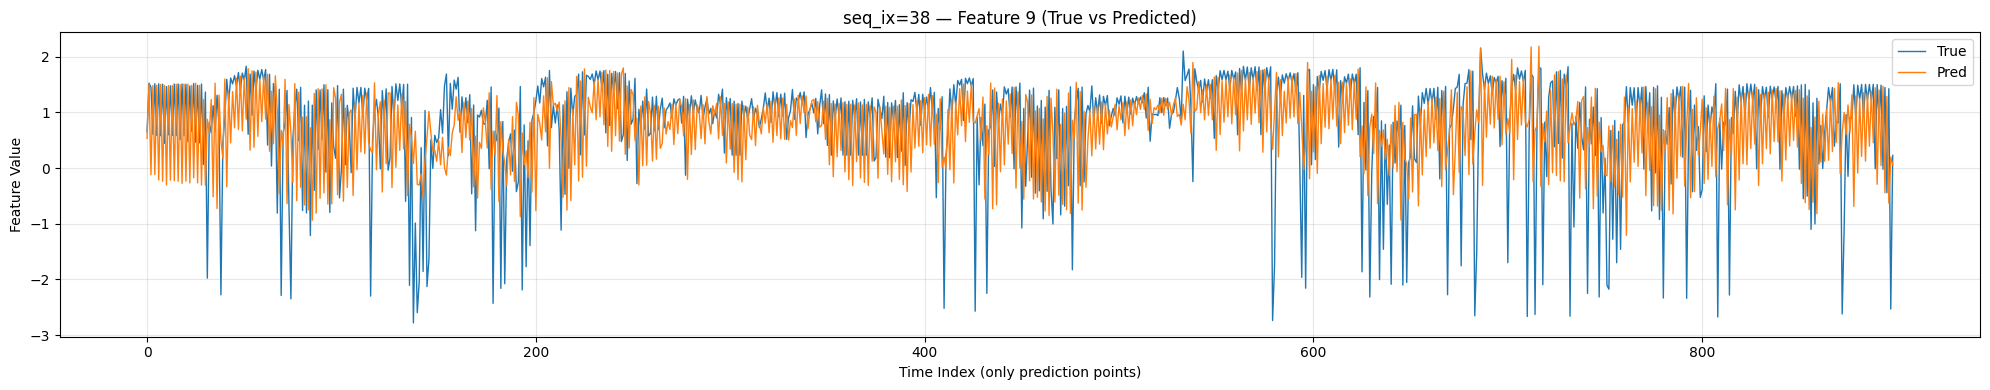

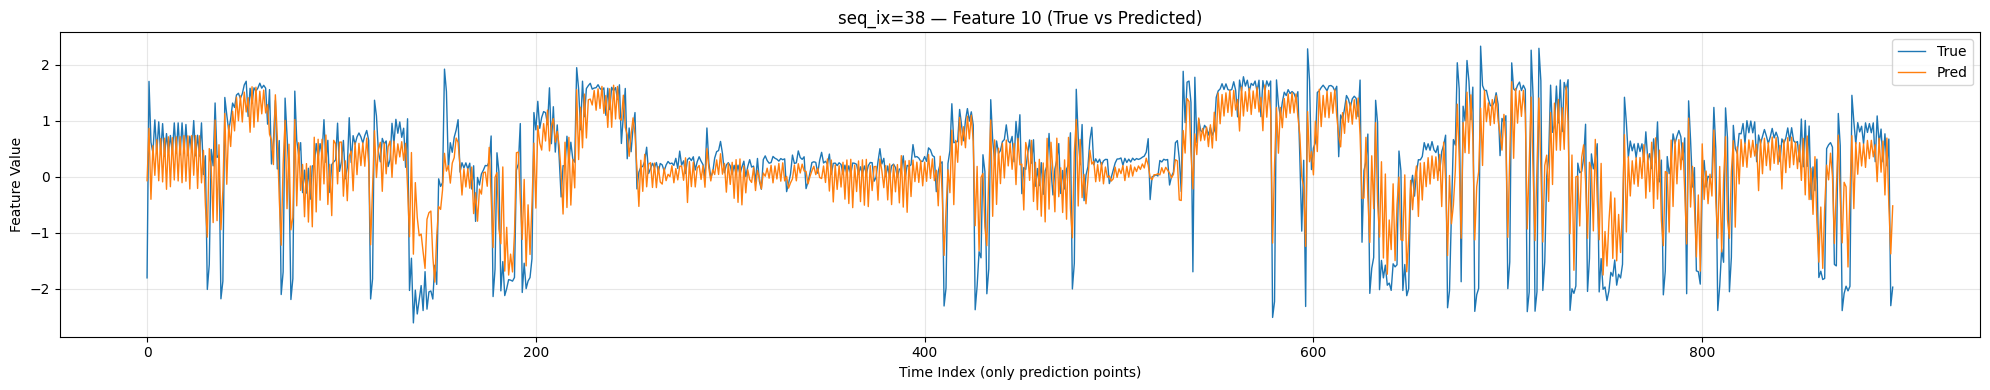

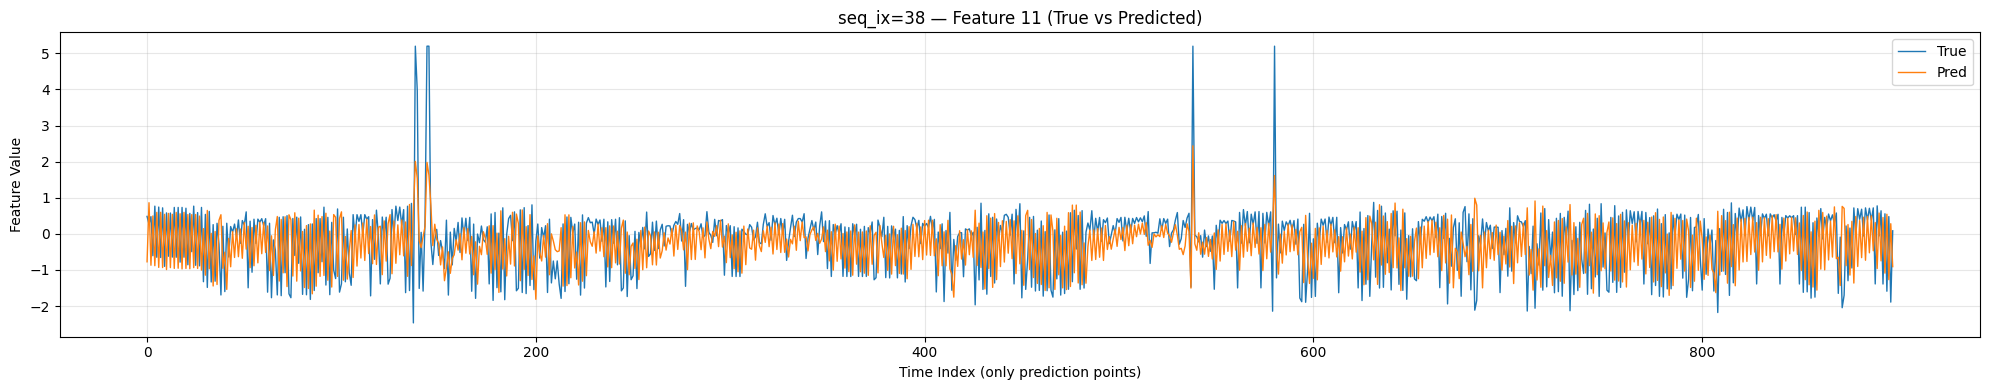

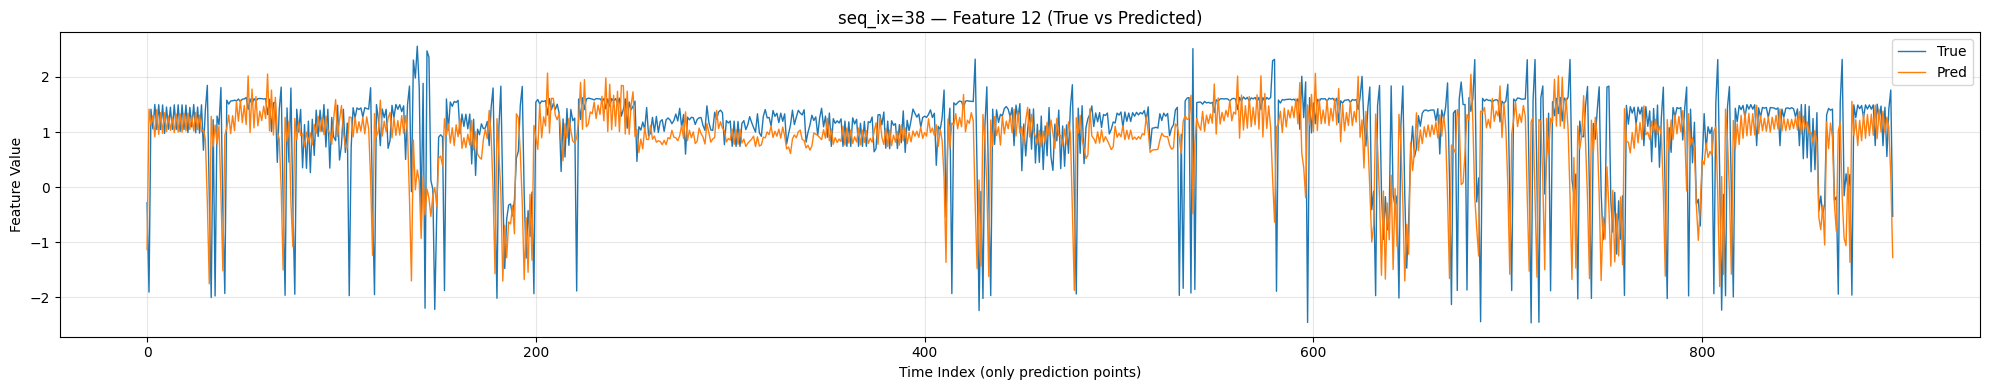

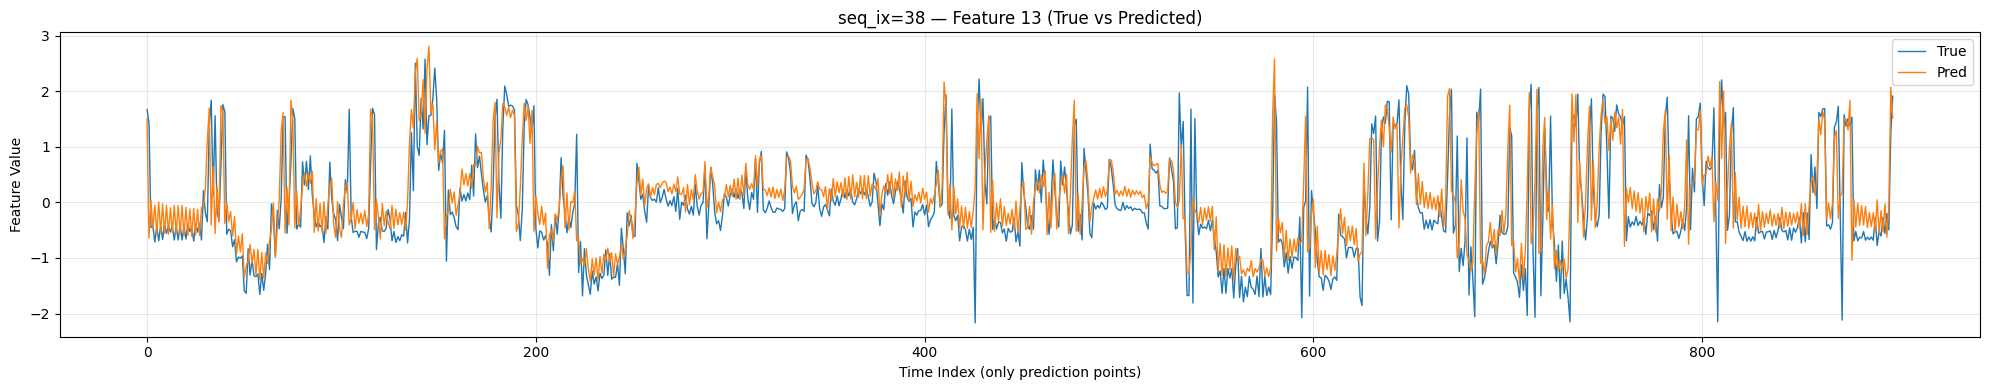

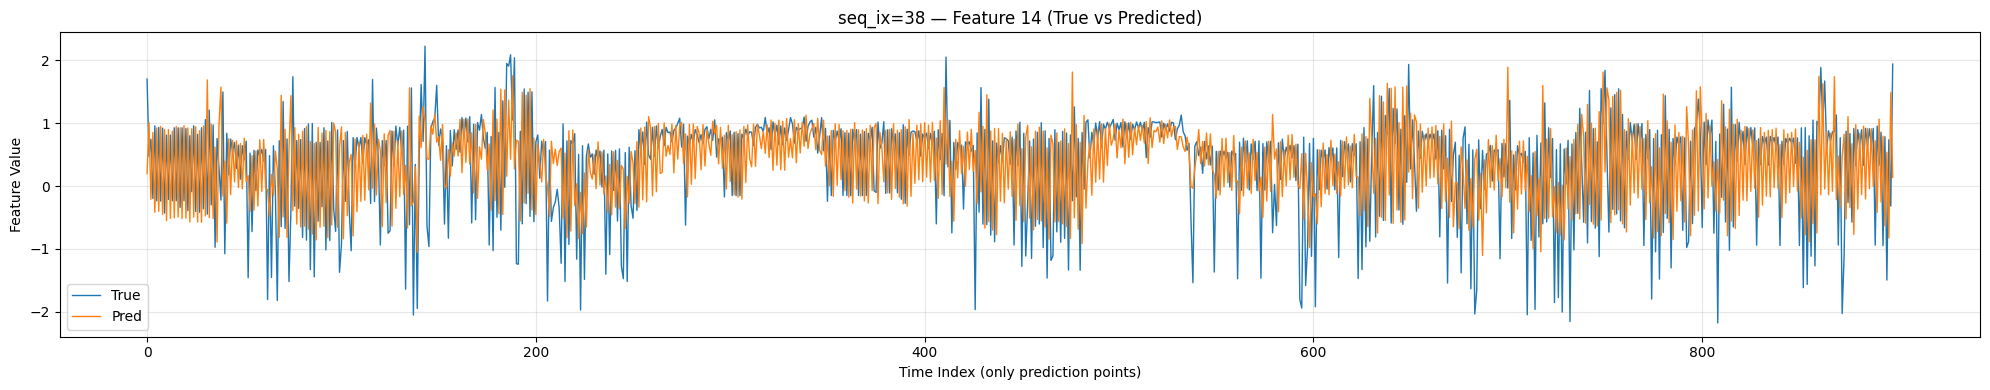

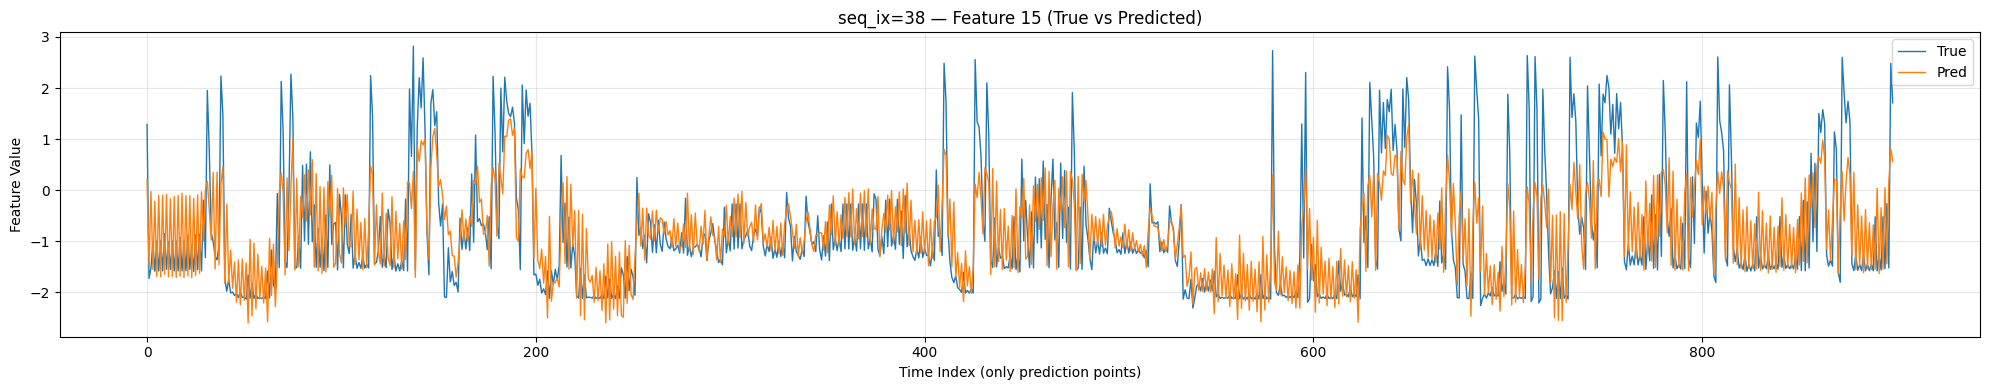

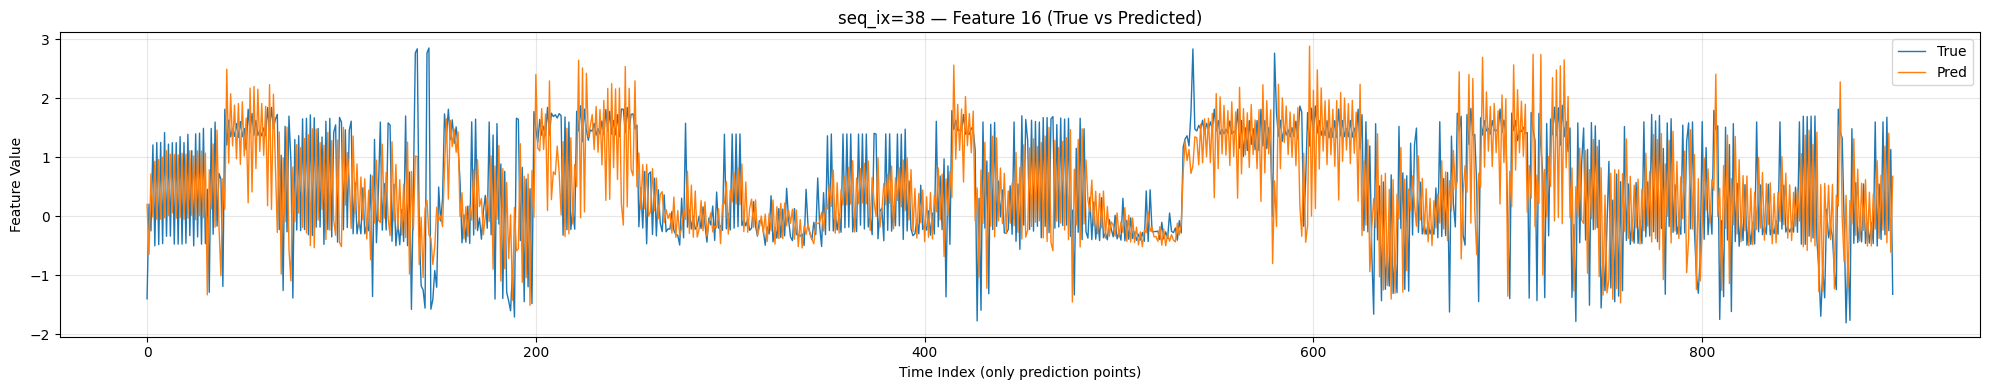

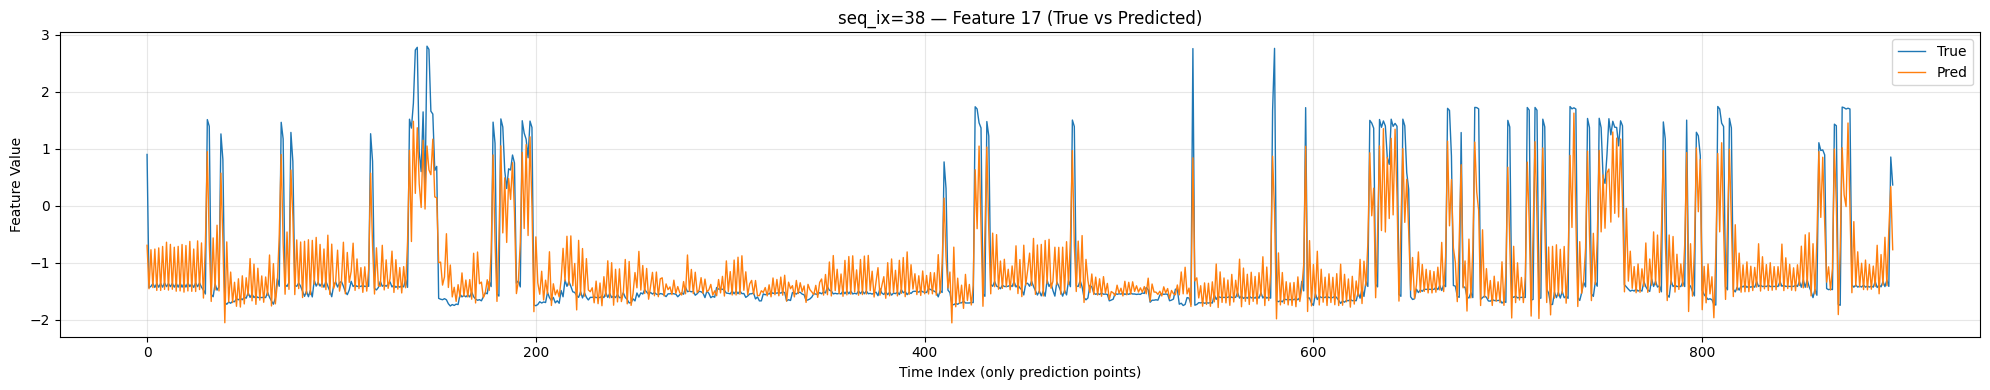

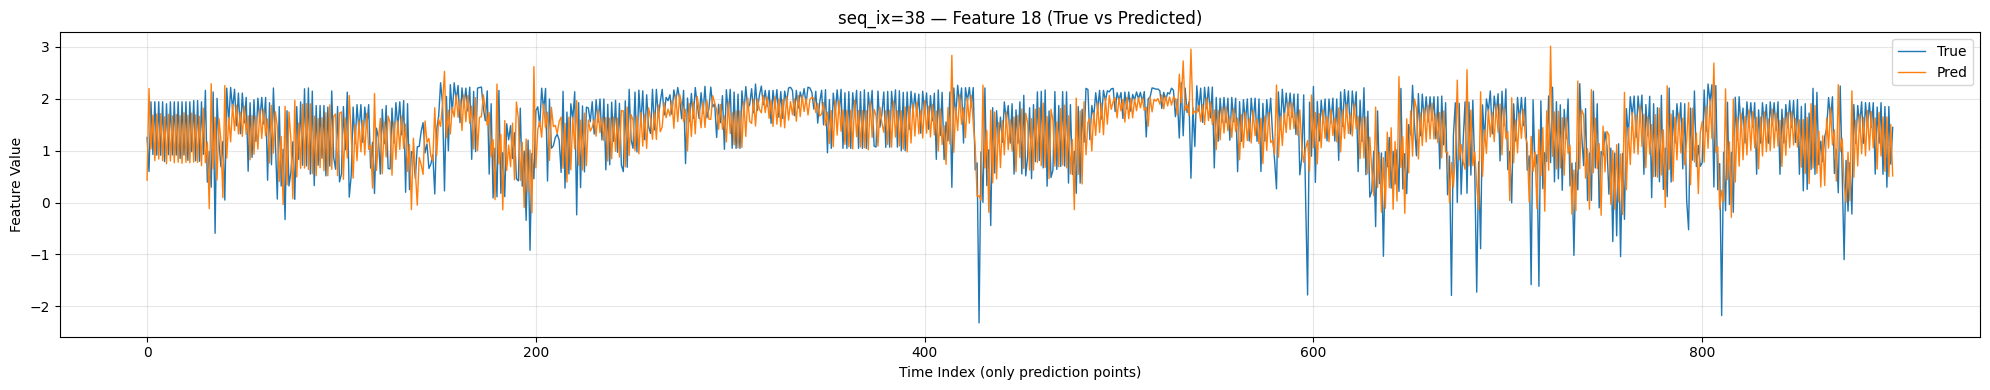

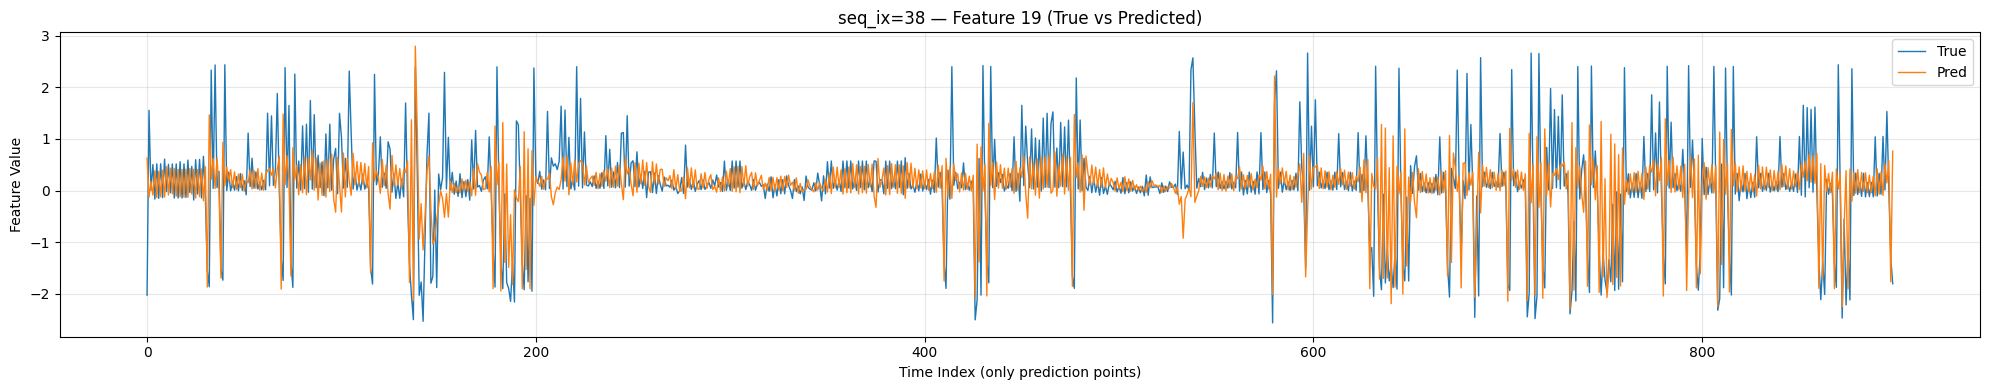

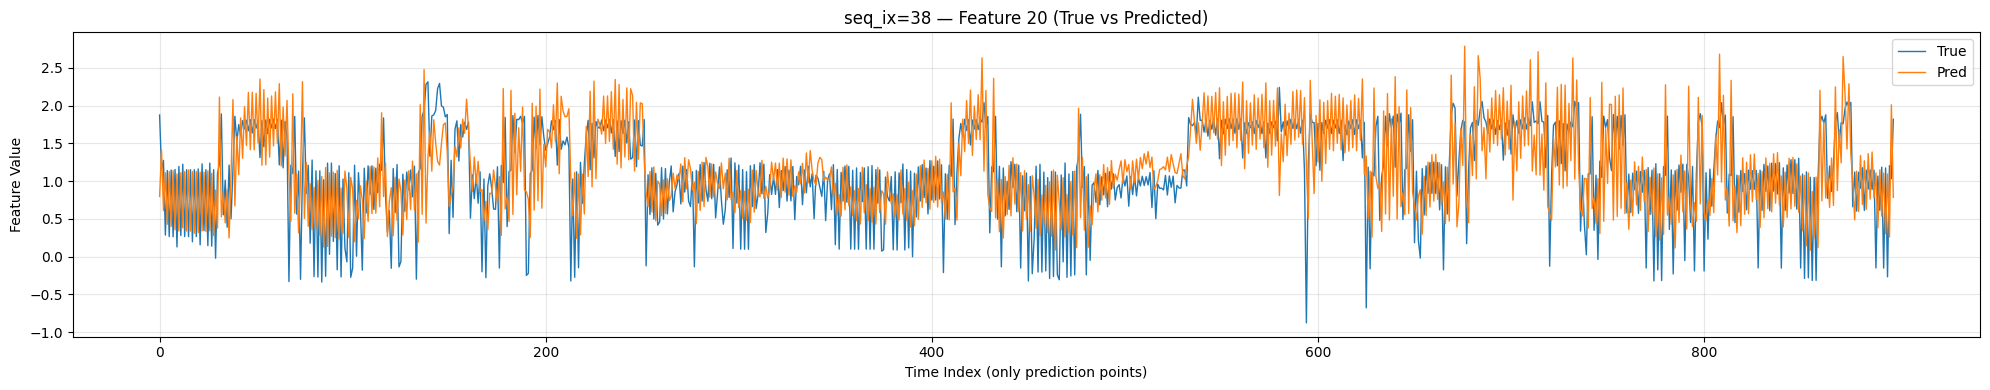

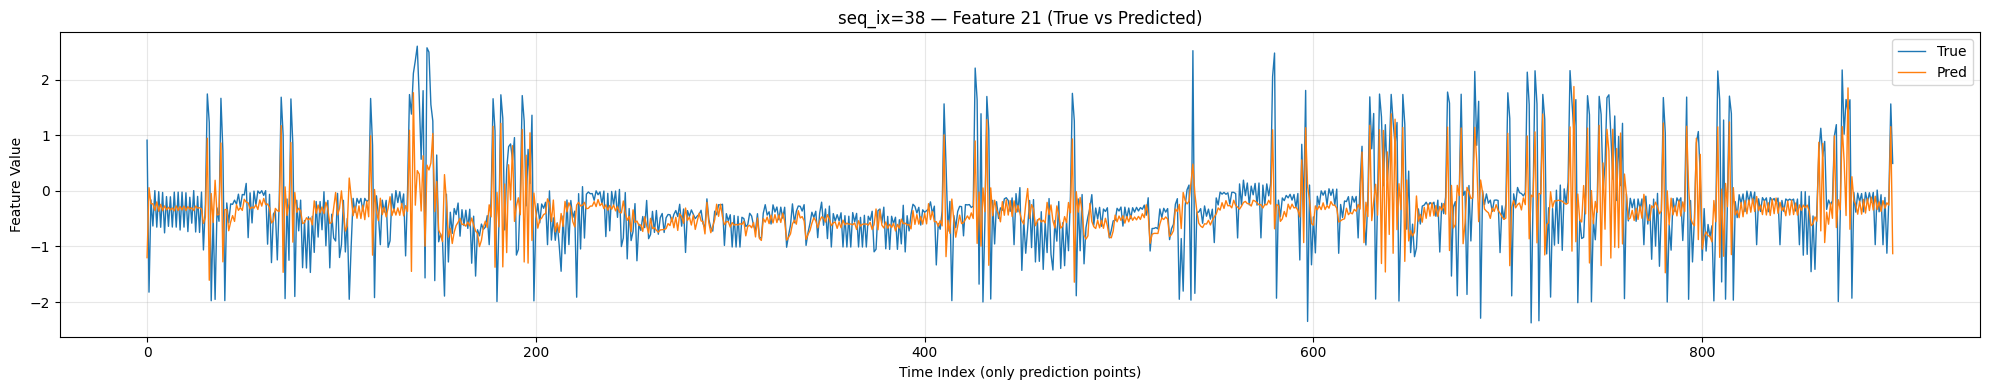

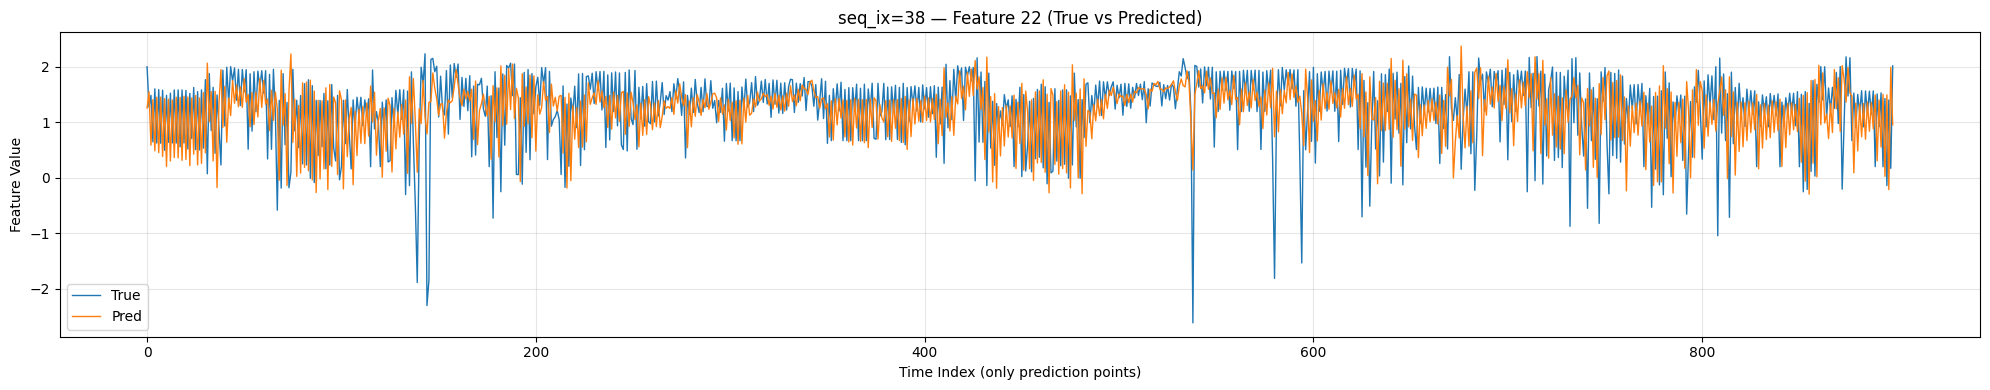

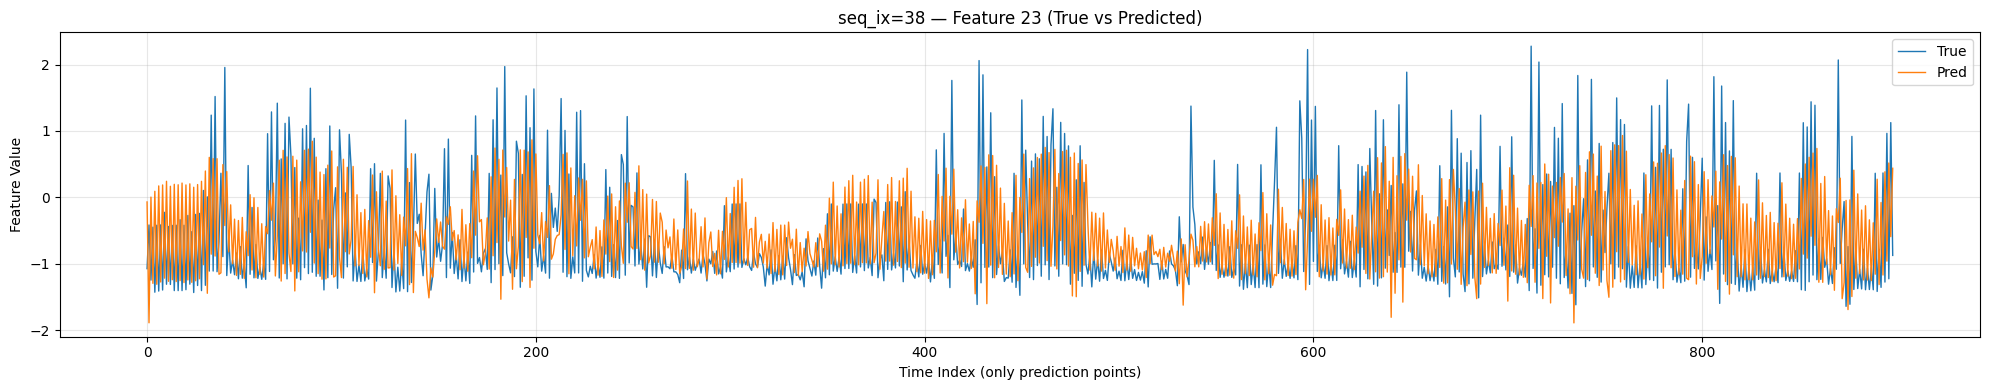

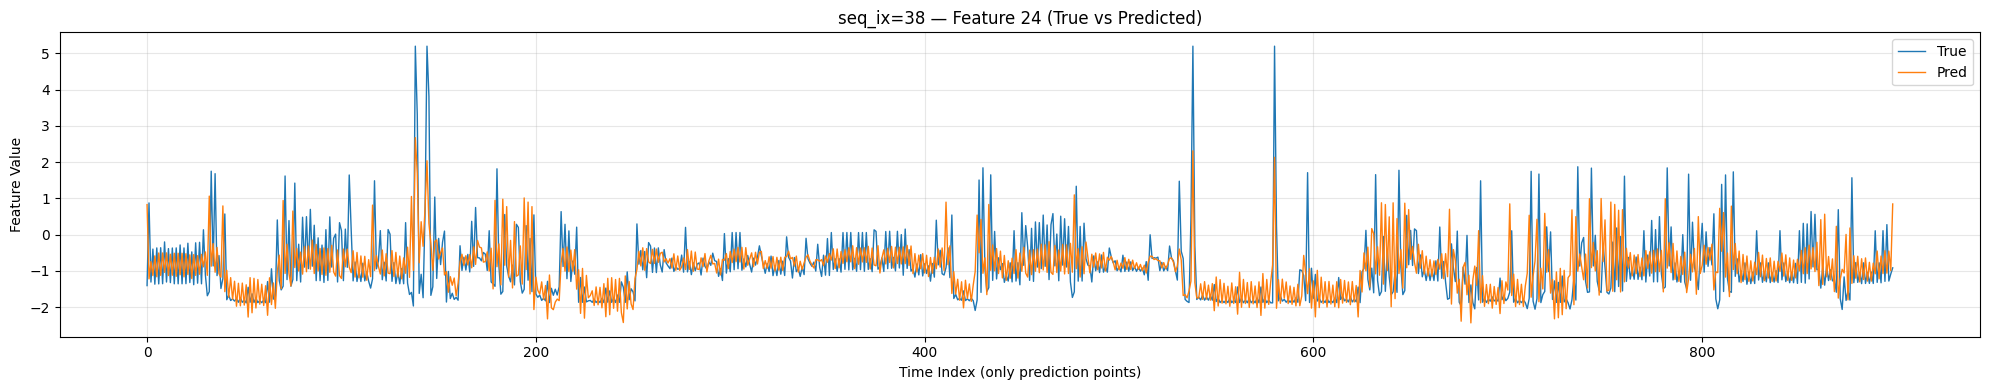

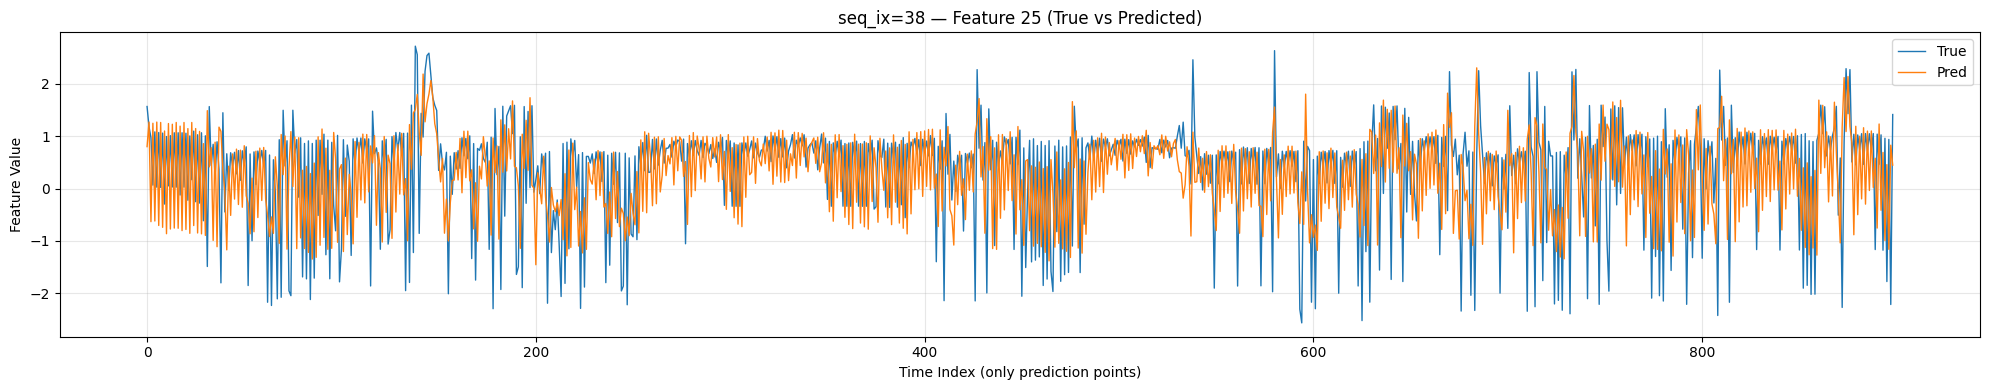

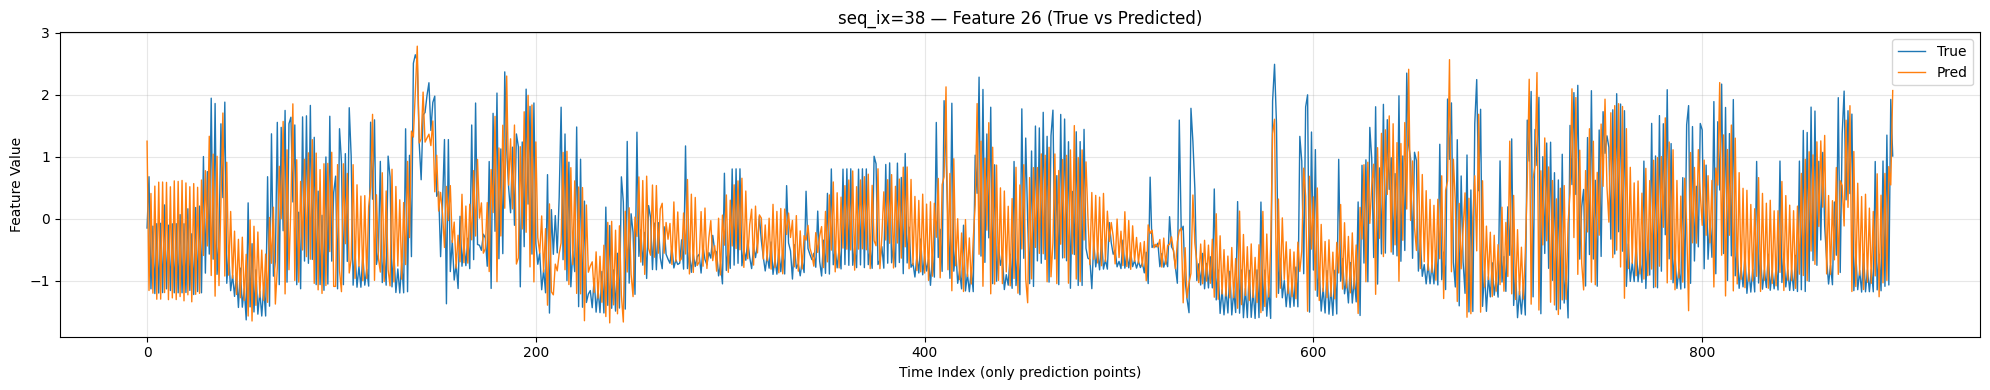

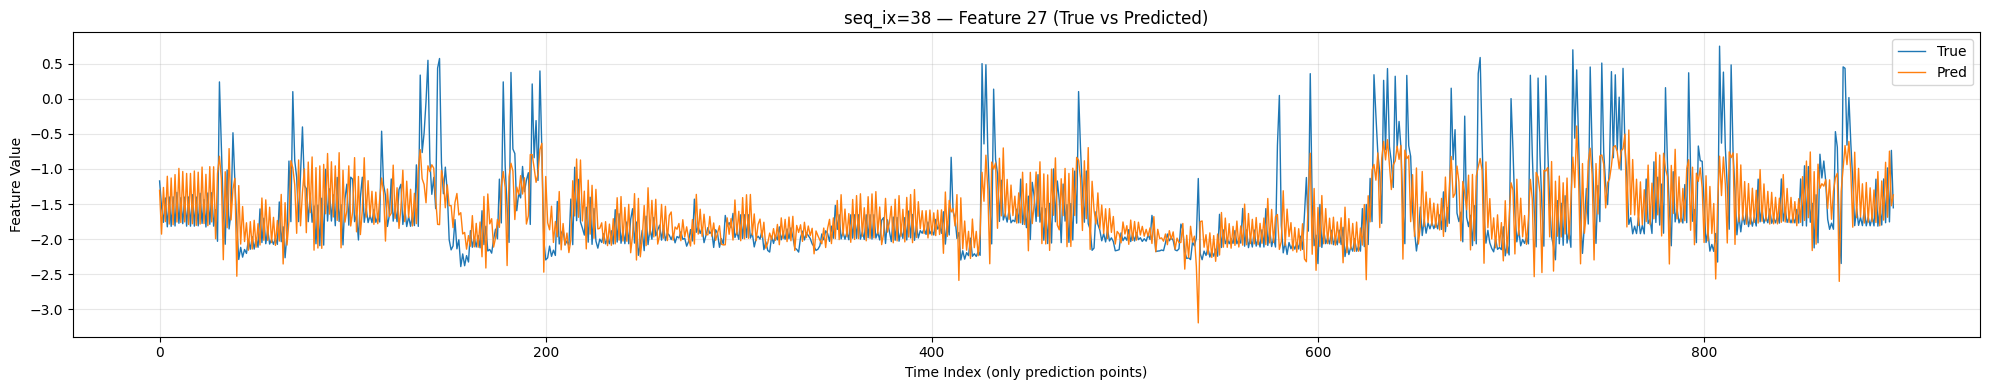

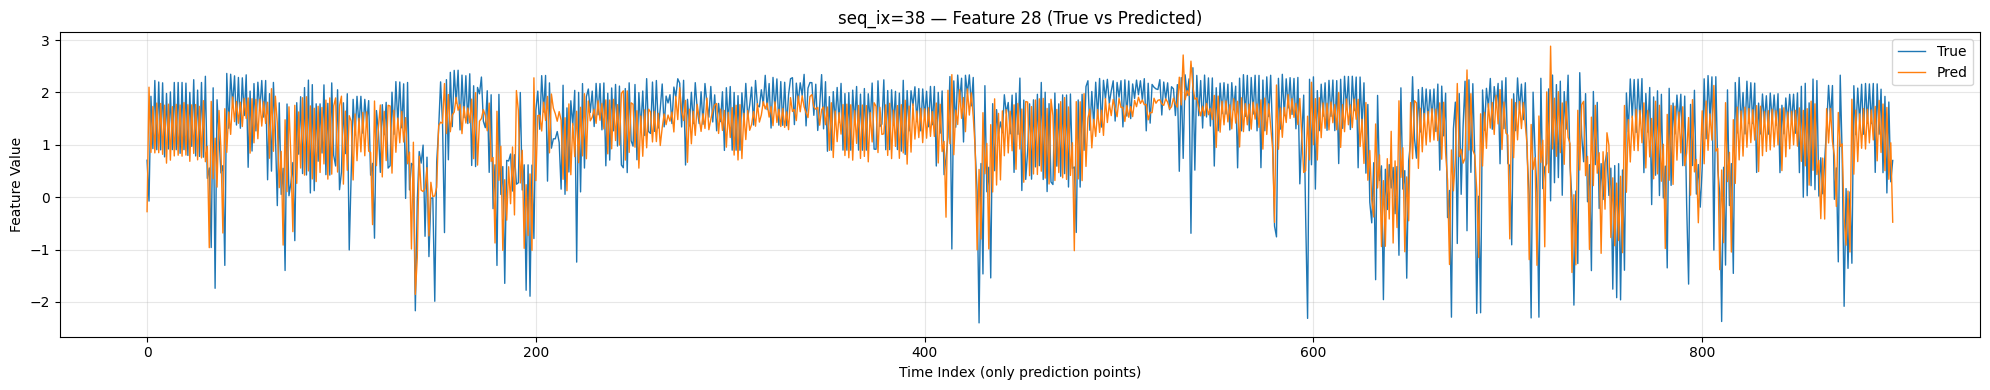

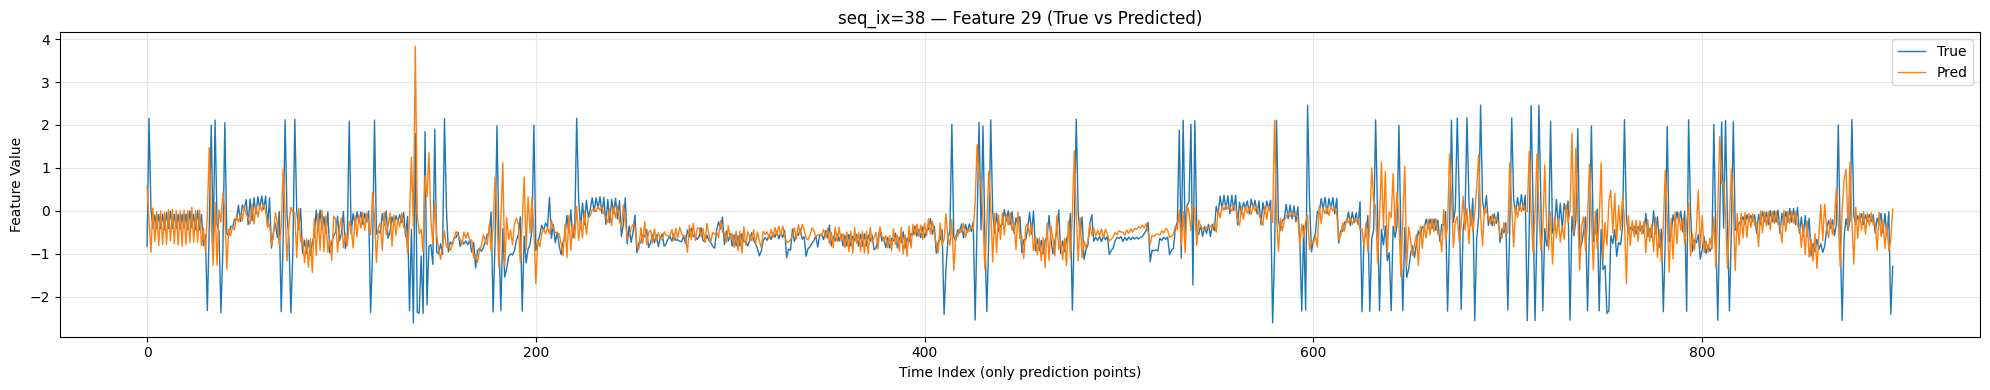

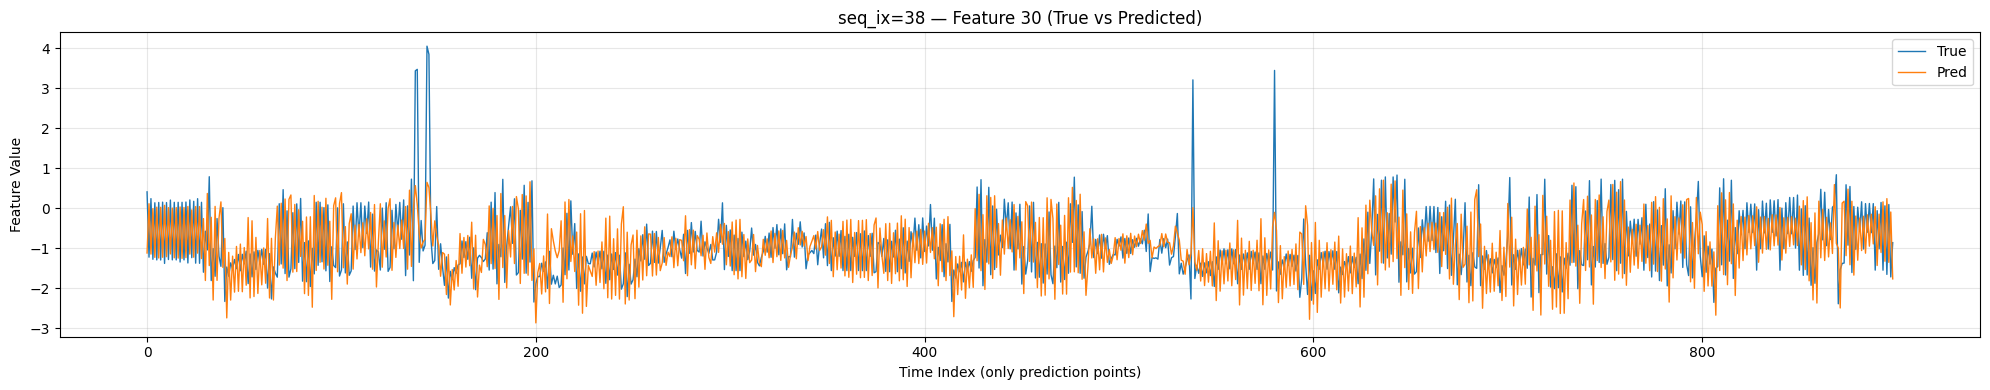

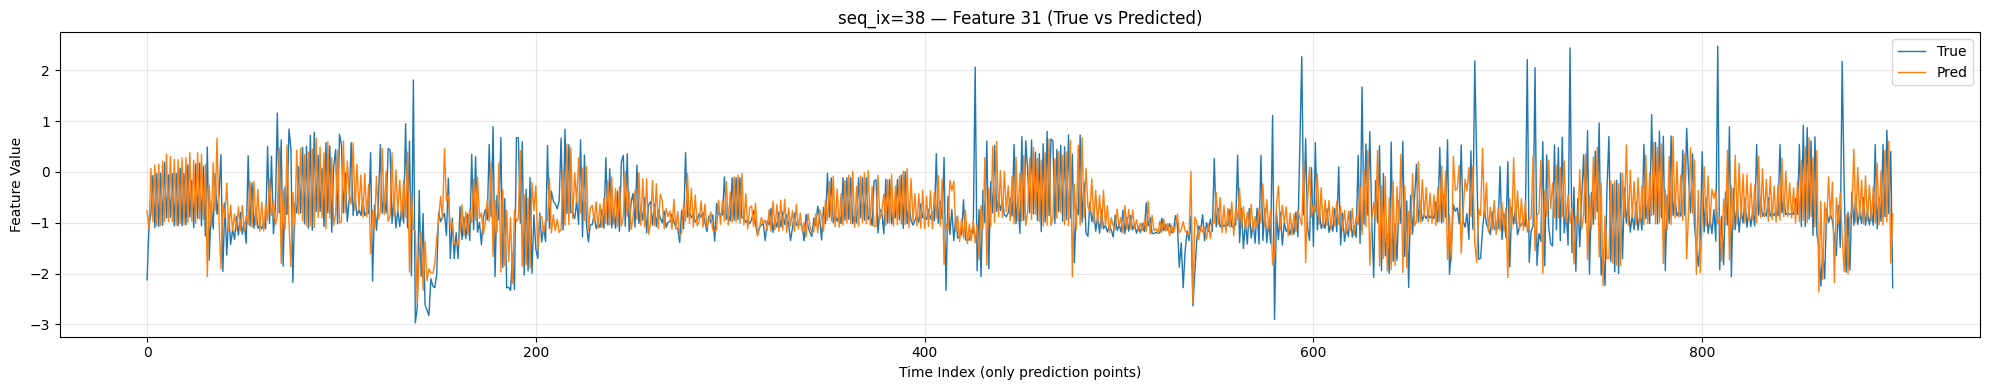


Done plotting ✓


In [2]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CURRENT_DIR = os.getcwd()   # folder where notebook is running
sys.path.append(f"{CURRENT_DIR}/../..")

from utils import ScorerStepByStep, DataPoint

# ------------------------------------------------------------
# Import PredictionModel from solution.py
# ------------------------------------------------------------
# (assumes solution.py is in the same folder as this notebook)
from solution import PredictionModel


# ------------------ Select which sequence to visualize ------------------
seq_to_plot = 38  # <---- change this to view a different seq_ix
# ------------------------------------------------------------------------


# Load dataset using scorer so we replicate real evaluation setup
train_file = f"{CURRENT_DIR}/../../datasets/train.parquet"
scorer = ScorerStepByStep(train_file)
df = scorer.dataset


# Extract dataframe for selected sequence in correct order
df_seq = df[df["seq_ix"] == seq_to_plot].sort_values("step_in_seq").reset_index(drop=True)

# Load model with saved weights and bias
model = PredictionModel()
model.eval()

pred_list = []
true_list = []

for _, row in df_seq.iterrows():
    dp = DataPoint(
        int(row["seq_ix"]),
        int(row["step_in_seq"]),
        bool(row["need_prediction"]),
        row[scorer.features].to_numpy(dtype=np.float32)
    )
    pred = model.predict(dp)

    if pred is not None:  # only store when scorer requires a prediction
        pred_list.append(pred)
        true_list.append(dp.state)

pred_arr = np.stack(pred_list)
true_arr = np.stack(true_list)

print("Prediction shape:", pred_arr.shape)
print("Truth shape:", true_arr.shape)

# ------------------------------------------------------------
# Plot results
# ------------------------------------------------------------
for k in range(32):
    plt.figure(figsize=(20, 4))
    plt.plot(true_arr[:, k], label="True", linewidth=1)
    plt.plot(pred_arr[:, k], label="Pred", linewidth=1)
    plt.title(f"seq_ix={seq_to_plot} — Feature {k} (True vs Predicted)")
    plt.xlabel("Time Index (only prediction points)")
    plt.ylabel("Feature Value")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

print("\nDone plotting ✓")
